# ScienceQA Hybrid RAG Pipeline Evaluation & Visualization

This notebook evaluates the ScienceQA Hybrid Retrieval-Augmented Generation (RAG) pipeline (BERT + TF-IDF) on the test set, reports accuracy by grade and subject, and visualizes the results.

In [31]:
# 1. Import Required Libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import os

## 2. Load Model and Data
Load the custom BERT model, TF-IDF vectorizer, and ScienceQA datasets.

In [32]:
import sys
import os
import json
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "models")))
from custom_bert import CustomBERTEmbedding

VOCAB_SIZE = 30522
EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 6
MAX_SEQ_LENGTH = 128

# Load model
model = CustomBERTEmbedding(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, MAX_SEQ_LENGTH)
model.load_state_dict(torch.load(os.path.join("..", "models", "custom_bert.pth"), map_location=torch.device('cpu')))
model.eval()

# Load data
data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
train_path = os.path.join(data_dir, "train.json")
test_path = os.path.join(data_dir, "test.json")
with open(train_path, 'r', encoding='utf-8') as f:
    data_train = json.load(f)
with open(test_path, 'r', encoding='utf-8') as f:
    data_test = json.load(f)

# Convert dict to list if needed
if isinstance(data_train, dict):
    data_train = list(data_train.values())
if isinstance(data_test, dict):
    data_test = list(data_test.values())

# Filter to only dict items
data_train = [item for item in data_train if isinstance(item, dict)]
data_test = [item for item in data_test if isinstance(item, dict)]

print(f"Train samples: {len(data_train)} | Test samples: {len(data_test)}")

/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_94847/206055539.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join

Train samples: 6517 | Test samples: 2195


## 3. Load or Compute BERT and TF-IDF Embeddings
Load precomputed BERT and TF-IDF embeddings for lectures, or compute and save them if not present.

In [33]:
def simple_tokenizer(text, vocab_size=VOCAB_SIZE, max_seq_length=MAX_SEQ_LENGTH):
    if not isinstance(text, str):
        text = str(text)
    tokens = text.lower().split()
    ids = [abs(hash(token)) % vocab_size for token in tokens]
    if len(ids) < max_seq_length:
        ids += [0] * (max_seq_length - len(ids))
    else:
        ids = ids[:max_seq_length]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)

def embed_text(model, text):
    input_ids = simple_tokenizer(text)
    with torch.no_grad():
        emb = model(input_ids)
        emb_vec = emb.mean(dim=1).squeeze().cpu().numpy()
    return emb_vec

def batch_embed_lectures(model, data, save_path):
    embs = []
    for item in tqdm(data, desc="Embedding lectures (BERT)"):
        lecture = item.get('lecture', '')
        embs.append(embed_text(model, lecture))
    embs = np.stack(embs)
    np.save(save_path, embs)
    print(f"Saved {len(embs)} BERT embeddings to {save_path}")

lectures = [item.get('lecture', '') for item in data_train]
bert_emb_path = os.path.join(data_dir, "lecture_embeddings.npy")
tfidf_path = os.path.join(data_dir, "lecture_tfidf.npz")
tfidf_vocab_path = os.path.join(data_dir, "tfidf_vocab.json")

# BERT embeddings
if not os.path.exists(bert_emb_path):
    batch_embed_lectures(model, data_train, bert_emb_path)
bert_embs = np.load(bert_emb_path)

# TF-IDF embeddings
if not os.path.exists(tfidf_path):
    vectorizer = TfidfVectorizer(max_features=4096)
    tfidf_matrix = vectorizer.fit_transform(lectures)
    from scipy import sparse
    sparse.save_npz(tfidf_path, tfidf_matrix)
    with open(tfidf_vocab_path, "w") as f:
        json.dump(vectorizer.vocabulary_, f)
else:
    from scipy import sparse
    tfidf_matrix = sparse.load_npz(tfidf_path)
    with open(tfidf_vocab_path, "r") as f:
        vocab = json.load(f)
    vectorizer = TfidfVectorizer(vocabulary=vocab)
    vectorizer.fit(lectures)

print(f"Loaded BERT embeddings: {bert_embs.shape}")
print(f"Loaded TF-IDF matrix: {tfidf_matrix.shape}")

Loaded BERT embeddings: (6311, 30522)
Loaded TF-IDF matrix: (6311, 2177)


## 4. Hybrid Retrieval and Evaluation on Test Set
Run hybrid retrieval (BERT + TF-IDF) for each test question and collect results.

In [44]:
import pandas as pd
import os

# Load precomputed hybrid RAG results from CSV
results_csv_path = os.path.join(data_dir, "rag_hybrid_results.csv")
results_df = pd.read_csv(results_csv_path)
print("Loaded results from:", results_csv_path)
print("Columns:", results_df.columns.tolist())
results_df.head()

Loaded results from: /Users/jessicalim/Desktop/UNSW/COMP9444/scienceqa-9444/data/rag_hybrid_results.csv
Columns: ['question', 'choices', 'ground_truth_index', 'predicted_index', 'grade', 'subject', 'is_correct']


,question,choices,ground_truth_index,predicted_index,grade,subject,is_correct
0,Which figure of speech is used in this text?\n...,"['paradox', 'oxymoron']",0,1.0,grade11,language science,False
1,Which of the following contains a vague pronou...,"[""If Lila's skirt doesn't match the blouse, sh...",1,1.0,grade11,language science,True
2,Which text message is more formal?,"[""Ms. Norton is already here. She's waiting in...",0,NaN,grade11,language science,False
3,Which logical fallacy is used in the text?\nSo...,"[""straw man: a misrepresentation of an opponen...",0,NaN,grade11,language science,False
4,Which figure of speech is used in this text?\n...,"['anaphora', 'hyperbole']",1,NaN,grade11,language science,False


## 5. Calculate Accuracy by Grade and Subject
Aggregate the results to compute accuracy for each grade and each subject.

In [55]:
# Robust grade binning for formats like 'grade11', 'Grade 11', etc.
import re

def extract_grade_num(grade):
    match = re.search(r'(\d+)', str(grade))
    return int(match.group(1)) if match else None

def grade_bin_v2(grade):
    g = extract_grade_num(grade)
    if g is None:
        return 'Other'
    if 1 <= g <= 6:
        return 'Primary (1-6)'
    elif 7 <= g <= 12:
        return 'Secondary (7-12)'
    else:
        return 'Other'

results_df['grade_num'] = results_df['grade'].apply(extract_grade_num)
results_df['grade_bin_v2'] = results_df['grade'].apply(grade_bin_v2)

print("results_df columns:", results_df.columns.tolist())
if results_df.empty:
    print("No results to process. Check your data and retrieval loop.")
else:
    display(results_df.head())
    print(f"Total test items: {len(results_df)}")
    print(f"Correct predictions: {results_df['is_correct'].sum()}")
    print(f"Accuracy: {results_df['is_correct'].mean():.3f}")

    # Accuracy by new grade bins
    acc_by_grade_bin_v2 = results_df.groupby('grade_bin_v2')['is_correct'].mean().sort_index()
    print("Accuracy by grade bin:")
    print(acc_by_grade_bin_v2)

    # Accuracy by subject
    acc_by_subject = results_df.groupby('subject')['is_correct'].mean().sort_values(ascending=False)
    print("\nAccuracy by subject:")
    print(acc_by_subject)

    # Accuracy by each grade (1-12)
    acc_by_grade = results_df.groupby('grade_num')['is_correct'].mean().reindex(range(1,13))
    print("\nAccuracy by individual grade (1-12):")
    print(acc_by_grade)

results_df columns: ['question', 'choices', 'ground_truth_index', 'predicted_index', 'grade', 'subject', 'is_correct', 'grade_num', 'grade_bin_v2']


,question,choices,ground_truth_index,predicted_index,grade,subject,is_correct,grade_num,grade_bin_v2
0,Which figure of speech is used in this text?\n...,"['paradox', 'oxymoron']",0,1.0,grade11,language science,False,11,Secondary (7-12)
1,Which of the following contains a vague pronou...,"[""If Lila's skirt doesn't match the blouse, sh...",1,1.0,grade11,language science,True,11,Secondary (7-12)
2,Which text message is more formal?,"[""Ms. Norton is already here. She's waiting in...",0,NaN,grade11,language science,False,11,Secondary (7-12)
3,Which logical fallacy is used in the text?\nSo...,"[""straw man: a misrepresentation of an opponen...",0,NaN,grade11,language science,False,11,Secondary (7-12)
4,Which figure of speech is used in this text?\n...,"['anaphora', 'hyperbole']",1,NaN,grade11,language science,False,11,Secondary (7-12)


Total test items: 2195
Correct predictions: 766
Accuracy: 0.349
Accuracy by grade bin:
grade_bin_v2
Primary (1-6)       0.375187
Secondary (7-12)    0.308051
Name: is_correct, dtype: float64

Accuracy by subject:
subject
social science      0.418033
natural science     0.356178
language science    0.333655
Name: is_correct, dtype: float64

Accuracy by individual grade (1-12):
grade_num
1     0.222222
2     0.432161
3     0.416949
4     0.365269
5     0.348276
6     0.326733
7     0.317829
8     0.350254
9     0.303030
10    0.303571
11    0.256881
12    0.256098
Name: is_correct, dtype: float64


## 6. Visualize Accuracy by Grade
Create a bar plot showing accuracy for each grade using matplotlib or seaborn.

/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_94847/1945174230.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_by_grade.index, y=acc_by_grade.values, palette="Blues_d")


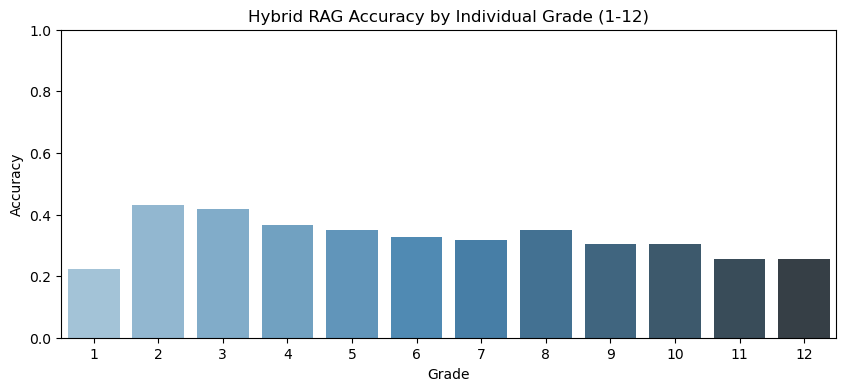

In [52]:
plt.figure(figsize=(10,4))
sns.barplot(x=acc_by_grade.index, y=acc_by_grade.values, palette="Blues_d")
plt.title("Hybrid RAG Accuracy by Individual Grade (1-12)")
plt.xlabel("Grade")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

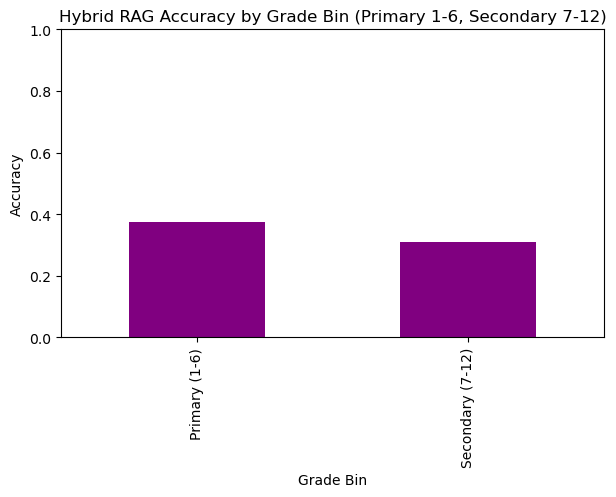

In [59]:
acc_by_grade_bin_v2 = results_df.groupby('grade_bin_v2')['is_correct'].mean().sort_index()
acc_by_grade_bin_v2.plot(kind='bar', figsize=(7,4), color='purple')
plt.title("Hybrid RAG Accuracy by Grade Bin (Primary 1-6, Secondary 7-12)")
plt.xlabel("Grade Bin")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## 7. Visualize Accuracy by Subject
Create a bar plot showing accuracy for each subject using matplotlib or seaborn.

/var/folders/7n/sdnmyc4j33q0y4lz8rx2m3wc0000gn/T/ipykernel_94847/938569818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acc_by_subject.index, y=acc_by_subject.values, palette="Greens_d")


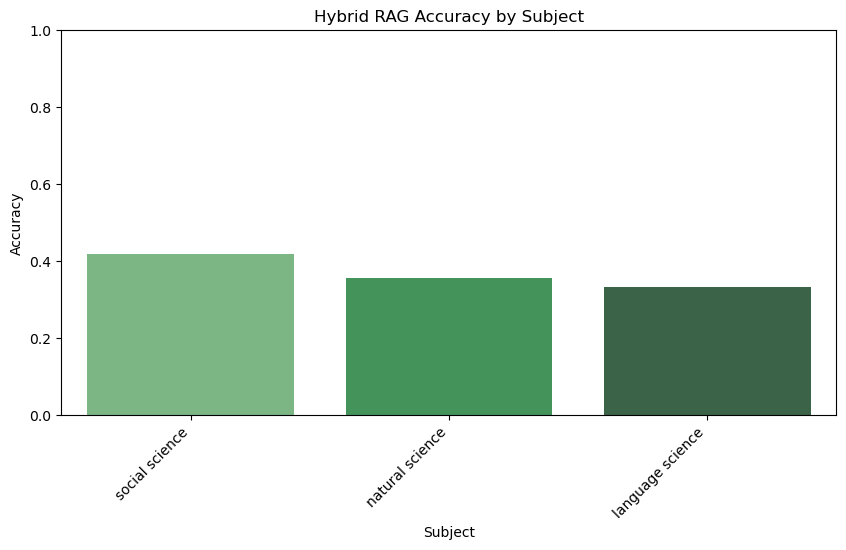

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(x=acc_by_subject.index, y=acc_by_subject.values, palette="Greens_d")
plt.title("Hybrid RAG Accuracy by Subject")
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()